# Lecture 04: Generating Functions

**Source span.** Printed pages 20-26; physical PDF pages 34-40 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Use functions on `X_1 x X_2` to generate Lagrangian submanifolds in `T^*(X_1 x X_2)`, then twist those Lagrangians into graphs of symplectomorphisms between cotangent bundles. The practical test is the mixed Hessian: if the equations `xi=d_x f` can be solved for `y`, the generated Lagrangian becomes a local symplectic map.

The lecture also shows why the Euclidean free-motion map and geodesic flow fit this framework. The generating function `-d(x,y)^2/2` encodes the endpoint relation for a minimizing geodesic. In flat space, solving the equations gives the shear `(x,xi)->(x+xi,xi)`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-04"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-04


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Product cotangent bundle | `T^*X_1 x T^*X_2 ~= T^*(X_1 x X_2)` | the tautological form is the sum of the two projected tautological forms |
| Twist involution | `(x_2,eta)->(x_2,-eta)` | it turns the plus product form into the twisted form used for graphs |
| Generating function `f` | exact one-form `df` on `X_1 x X_2` | `Y_f=graph(df)` is Lagrangian before twisting |
| Twisted generated set | `(x,y,d_x f,-d_y f)` | it is a symplectomorphism graph only when the projection to `(x,xi)` is locally invertible |
| Mixed Hessian condition | matrix `d_y d_x f` | nonzero determinant lets the implicit function theorem solve `xi=d_x f` for `y` |
| Quadratic example | `f=-(x-y)^2/2` | solves to `(x,xi)->(x+xi,xi)` and the residual preserves `dx wedge dxi` |
| Riemannian metric | identification `g_x:T_xX -> T_x^*X` | converts cotangent equations into geodesic endpoint and velocity data |
| Geodesic flow homework | action, arc length, exponential map | constant-speed minimizing geodesics are the action minimizers that the generating function records |

## Library Routing

This lecture is an implicit-function and residual-check chapter. `sympy` differentiates generating functions and verifies Hamilton equations exactly; `numpy` checks the symplectic matrix residual of the generated map; `matplotlib` draws contours, mixed-Hessian failure, and Euclidean geodesic flow; `networkx` shows the recipe from exact graph to twisted graph to symplectomorphism. These libraries match the chapter's actual invariants: exactness, invertibility, and form preservation.

## Visual Storyboard

The chapter-specific artifacts are:

1. **Quadratic generating function map.** Contours of `f=-(x-y)^2/2` sit next to the induced shear `(x,xi)->(x+xi,xi)`.
2. **Mixed-Hessian gate.** A good generating function has nonzero `d_y d_x f`; a degenerate example shows where the graph projection can fold.
3. **Twist recipe.** The product-form Lagrangian is flipped in the second cotangent fiber to become a candidate graph for the twisted product form.
4. **Geodesic flow.** The Euclidean case visualizes the lecture's general statement: the distance-squared generating function maps initial velocity to endpoint velocity.
5. **Proof route.** A dependency graph links exact graphs, the twist, mixed Hessian, and geodesic flow.

In [2]:
# Visual 1: the quadratic generating function and its induced free-motion shear.
x_vals = np.linspace(-2.0, 2.0, 220)
y_vals = np.linspace(-2.0, 2.0, 220)
X, Y = np.meshgrid(x_vals, y_vals)
F = -0.5 * (X - Y) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9))
cs = axes[0].contour(X, Y, F, levels=12, cmap="viridis")
axes[0].clabel(cs, inline=True, fontsize=7)
for xi0 in [-1.0, -0.5, 0.0, 0.7, 1.2]:
    axes[0].plot(x_vals, x_vals + xi0, lw=1.3, label=f"xi={xi0:g}")
axes[0].set_title("Solving xi=d_x f gives y=x+xi")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].set_title("Generated symplectomorphism: free translation")
x0 = np.linspace(-1.6, 1.6, 7)
xi0 = np.linspace(-1.2, 1.2, 7)
XX, XI = np.meshgrid(x0, xi0)
Ymap = XX + XI
ETA = XI
axes[1].quiver(XX, XI, Ymap - XX, ETA - XI, color="#1d3557", angles="xy", scale_units="xy", scale=1, width=0.004)
axes[1].scatter(XX, XI, s=12, color="#e76f51", zorder=3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("xi")
axes[1].text(0.05, 0.92, "eta=xi; y=x+xi", transform=axes[1].transAxes, bbox={"boxstyle": "round,pad=0.3", "fc": "#e8f3ee", "ec": "#4d908e"})
axes[1].spines[["top", "right"]].set_visible(False)
quad_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "quadratic-generating-function-free-motion.png")
plt.close(fig)
print(quad_path.relative_to(BOOK_ROOT))
assert quad_path.exists()

artifacts\lecture-04\figures\quadratic-generating-function-free-motion.png


In [3]:
# Visual 2: mixed Hessian gate and a degenerate failure mode.
Xh, Yh = np.meshgrid(np.linspace(-1.5, 1.5, 180), np.linspace(-1.5, 1.5, 180))
good_mixed = np.ones_like(Xh)
bad_mixed = 3 * (Xh - Yh) ** 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharex=True, sharey=True)
for ax, data, title in [
    (axes[0], good_mixed, "good: det(d_y d_x f)=1"),
    (axes[1], bad_mixed, "degenerate: determinant vanishes on x=y"),
]:
    im = ax.imshow(data, extent=[-1.5, 1.5, -1.5, 1.5], origin="lower", cmap="magma", vmin=0, vmax=3)
    ax.plot([-1.5, 1.5], [-1.5, 1.5], color="#8ecae6", lw=1.5, ls="--")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, shrink=0.8, label="mixed Hessian magnitude")
hessian_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "mixed-hessian-implicit-function-gate.png")
plt.close(fig)
print(hessian_path.relative_to(BOOK_ROOT))
assert np.all(good_mixed > 0)
assert np.min(bad_mixed) == 0

artifacts\lecture-04\figures\mixed-hessian-implicit-function-gate.png


In [4]:
# Visual 3: the twist recipe from exact graph to symplectomorphism graph.
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")
steps = [
    ("1. exact graph", "Y_f = graph(df)\nLagrangian in plus product"),
    ("2. twist", "sigma_2 flips eta\nY_f^sigma=(x,y,d_x f,-d_y f)"),
    ("3. projection test", "(x,y)->(x,d_x f)\nneeds mixed Hessian det nonzero"),
    ("4. graph", "phi(x,xi)=(y,eta)\nis symplectic"),
]
xs = np.linspace(0.1, 0.9, len(steps))
for idx, ((title, body), x0) in enumerate(zip(steps, xs)):
    ax.text(x0, 0.58, title, ha="center", va="center", weight="bold", bbox={"boxstyle": "round,pad=0.35", "fc": "#244b5a", "ec": "#1f2937"}, color="white")
    ax.text(x0, 0.34, body, ha="center", va="center", bbox={"boxstyle": "round,pad=0.42", "fc": "#f4f7fb", "ec": "#8d99ae"})
    if idx < len(steps) - 1:
        ax.annotate("", xy=(xs[idx+1]-0.09, 0.46), xytext=(x0+0.09, 0.46), arrowprops={"arrowstyle": "->", "lw": 2, "color": "#495057"})
ax.text(0.5, 0.08, "The twist converts the product canonical form into the twisted product form used by the graph criterion.", ha="center")
twist_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "generating-function-twist-recipe.png")
plt.close(fig)
print(twist_path.relative_to(BOOK_ROOT))
assert twist_path.exists()

artifacts\lecture-04\figures\generating-function-twist-recipe.png


In [5]:
# Visual 4: Euclidean geodesic flow from the distance-squared generating function.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.set_title("Euclidean geodesic: y=x+v")
starts = np.array([[-1.5, -0.9], [-1.2, 0.5], [0.0, -0.6], [0.7, 0.4]])
vels = np.array([[1.0, 0.7], [0.7, -0.35], [1.2, 0.45], [0.55, 0.9]])
for start, vel in zip(starts, vels):
    end = start + vel
    ax.plot([start[0], end[0]], [start[1], end[1]], color="#1d3557", lw=2)
    ax.scatter([start[0]], [start[1]], color="#e76f51", zorder=3)
    ax.scatter([end[0]], [end[1]], color="#90be6d", zorder=3)
    ax.arrow(start[0], start[1], 0.35*vel[0], 0.35*vel[1], head_width=0.06, color="#e76f51", length_includes_head=True)
ax.set_aspect("equal")
ax.set_xlabel("position")
ax.set_ylabel("position")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.set_title("Action detects constant-speed parametrization")
s = np.linspace(0, 1, 200)
constant_speed_action = np.ones_like(s)
reparam_speed_squared = (2*s)**2
ax.plot(s, constant_speed_action, label="constant speed: |gamma'|^2=1", color="#1d3557")
ax.plot(s, reparam_speed_squared, label="same path, tau=t^2: |(gamma o tau)'|^2", color="#e76f51")
ax.fill_between(s, constant_speed_action, alpha=0.16, color="#1d3557")
ax.fill_between(s, reparam_speed_squared, alpha=0.16, color="#e76f51")
ax.text(0.1, 3.15, "area under curve = action", fontsize=9)
ax.set_xlabel("time")
ax.set_ylabel("speed squared")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
geodesic_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "geodesic-flow-distance-generating-function.png")
plt.close(fig)
print(geodesic_path.relative_to(BOOK_ROOT))
assert geodesic_path.exists()

artifacts\lecture-04\figures\geodesic-flow-distance-generating-function.png


In [6]:
# Visual 5: proof route.
G = nx.DiGraph()
edges = [
    ("T^*X1 x T^*X2", "plus canonical form"),
    ("plus canonical form", "exact graph Y_f"),
    ("function f on X1 x X2", "df closed"),
    ("df closed", "exact graph Y_f"),
    ("twist sigma_2", "twisted product form"),
    ("exact graph Y_f", "twisted Y_f^sigma"),
    ("twisted product form", "twisted Y_f^sigma"),
    ("twisted Y_f^sigma", "Hamilton equations"),
    ("Hamilton equations", "mixed Hessian gate"),
    ("mixed Hessian gate", "local symplectomorphism"),
    ("quadratic f", "free translation"),
    ("distance squared f", "geodesic flow"),
    ("constant-speed minimizer", "geodesic flow"),
]
G.add_edges_from(edges)
pos = {
    "T^*X1 x T^*X2": (0, 1.0),
    "plus canonical form": (1.6, 1.0),
    "function f on X1 x X2": (0, -0.1),
    "df closed": (1.6, -0.1),
    "exact graph Y_f": (3.2, 0.45),
    "twist sigma_2": (3.2, -0.85),
    "twisted product form": (4.8, -0.85),
    "twisted Y_f^sigma": (4.8, 0.2),
    "Hamilton equations": (6.4, 0.2),
    "mixed Hessian gate": (8.0, 0.2),
    "local symplectomorphism": (9.8, 0.2),
    "quadratic f": (6.4, 1.35),
    "free translation": (8.0, 1.35),
    "distance squared f": (6.4, -1.15),
    "constant-speed minimizer": (8.0, -1.15),
    "geodesic flow": (9.8, -1.15),
}
fig, ax = plt.subplots(figsize=(12.5, 5.4))
colors = ["#8ecae6" if "form" in node or "df" in node else "#90be6d" if "symplectomorphism" in node or "flow" in node else "#f9c74f" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.3, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1700, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5)
ax.set_axis_off()
ax.set_title("Lecture 04 proof route: exact graph, twist, mixed Hessian, geodesic flow")
route_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "generating-functions-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G, "function f on X1 x X2", "local symplectomorphism")
assert nx.has_path(G, "distance squared f", "geodesic flow")

artifacts\lecture-04\figures\generating-functions-proof-route.png


In [7]:
# Exact checks for the generating-function construction.
x, y, xi, eta = sp.symbols("x y xi eta", real=True)
f = -sp.Rational(1, 2) * (x - y) ** 2
fx = sp.diff(f, x)
fy = sp.diff(f, y)
mixed_hessian = sp.diff(fx, y)
solution_y = sp.solve(sp.Eq(xi, fx), y)[0]
solution_eta = sp.simplify(-fy.subs(y, solution_y))

omega2 = np.array([[0.0, 1.0], [-1.0, 0.0]])
free_motion_matrix = np.array([[1.0, 1.0], [0.0, 1.0]])
free_motion_residual = float(np.linalg.norm(free_motion_matrix.T @ omega2 @ free_motion_matrix - omega2))

# Twist matrix check in coordinates (x1,xi1,x2,xi2): sigma flips xi2.
omega_plus = np.block([[omega2, np.zeros((2, 2))], [np.zeros((2, 2)), omega2]])
omega_twisted = np.block([[omega2, np.zeros((2, 2))], [np.zeros((2, 2)), -omega2]])
sigma = np.diag([1.0, 1.0, 1.0, -1.0])
twist_residual = float(np.linalg.norm(sigma.T @ omega_twisted @ sigma - omega_plus))

bad_f = -sp.Rational(1, 4) * (x - y) ** 4
bad_mixed = sp.diff(sp.diff(bad_f, x), y)
bad_mixed_at_diagonal = sp.simplify(bad_mixed.subs(y, x))

# Action and length for the same unit segment with two parametrizations.
s = sp.symbols("s", nonnegative=True)
constant_length = sp.integrate(1, (s, 0, 1))
reparam_length = sp.integrate(2*s, (s, 0, 1))
constant_action = sp.integrate(1, (s, 0, 1))
reparam_action = sp.integrate((2*s) ** 2, (s, 0, 1))

checks = {
    "lecture": 4,
    "quadratic_generating_function": {
        "f_x": str(fx),
        "minus_f_y": str(-fy),
        "mixed_hessian": str(mixed_hessian),
        "solution_y": str(solution_y),
        "solution_eta": str(solution_eta),
        "free_motion_symplectic_residual": free_motion_residual,
    },
    "twist": {
        "sigma_pullback_twisted_equals_plus_residual": twist_residual,
        "passed": bool(twist_residual < 1e-12),
    },
    "mixed_hessian_gate": {
        "good_nonzero": bool(mixed_hessian != 0),
        "bad_mixed_hessian": str(bad_mixed),
        "bad_zero_on_diagonal": bool(bad_mixed_at_diagonal == 0),
    },
    "geodesic_homework": {
        "constant_length": str(constant_length),
        "reparam_length": str(reparam_length),
        "constant_action": str(constant_action),
        "reparam_action": str(reparam_action),
        "same_length": bool(sp.simplify(constant_length - reparam_length) == 0),
        "constant_speed_smaller_action": bool(reparam_action > constant_action),
    },
}
checks["passed"] = bool(
    mixed_hessian == 1
    and sp.simplify(solution_y - (x + xi)) == 0
    and sp.simplify(solution_eta - xi) == 0
    and free_motion_residual < 1e-12
    and twist_residual < 1e-12
    and checks["mixed_hessian_gate"]["bad_zero_on_diagonal"]
    and checks["geodesic_homework"]["same_length"]
    and checks["geodesic_homework"]["constant_speed_smaller_action"]
)
check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "generating-function-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert free_motion_residual < 1e-12
assert twist_residual < 1e-12
assert mixed_hessian == 1

artifacts\lecture-04\checks\generating-function-residuals.json


## Reading The Visuals

The quadratic contour plot is the lecture's basic example in executable form. The equation `xi=d_x f` becomes `xi=y-x`, so every horizontal cotangent input selects a line `y=x+xi`. The second equation gives `eta=xi`, producing the shear `(x,xi)->(x+xi,xi)`. The residual check confirms that this shear preserves the canonical two-form.

The mixed-Hessian figure is the implicit-function theorem gate. A generating function always gives a Lagrangian graph before twisting, but it gives a symplectomorphism only when the twisted set projects cleanly to the source cotangent bundle. Where the mixed Hessian vanishes, the equations can fold or fail to solve for `y`.

The geodesic-flow plot explains the Riemannian application without hiding the variational content. In Euclidean space the geodesic is the straight segment with constant velocity. Reparametrizing the same segment preserves length but increases action unless the speed is constant, matching the homework statement that action minimizers are constant-speed length minimizers.

In [8]:
source_span = {
    "lecture": 4,
    "label": "Lecture 04",
    "title": "Generating Functions",
    "printed_span": "20-26",
    "physical_pdf_span": "34-40",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 4,
    "title": "Generating Functions",
    "source_span": source_span,
    "chapter_goal": "Make exact graphs, twisting, mixed-Hessian invertibility, free motion, and geodesic flow visually and computationally inspectable.",
    "library_routing": [
        {"library": "sympy", "use": "generating-function derivatives, mixed Hessian, and action checks"},
        {"library": "numpy", "use": "symplectic residuals for generated linear maps"},
        {"library": "matplotlib", "use": "contours, Hessian gate, twist recipe, and geodesic-flow diagrams"},
        {"library": "networkx", "use": "proof-route dependency graph"},
    ],
    "visual_sequence": [
        {"concept": "quadratic generating function and free motion", "artifact": "artifacts/lecture-04/figures/quadratic-generating-function-free-motion.png", "inspection_target": "Hamilton equations solve to y=x+xi and eta=xi"},
        {"concept": "mixed Hessian implicit-function gate", "artifact": "artifacts/lecture-04/figures/mixed-hessian-implicit-function-gate.png", "inspection_target": "nonzero mixed Hessian prevents projection folding"},
        {"concept": "twist recipe", "artifact": "artifacts/lecture-04/figures/generating-function-twist-recipe.png", "inspection_target": "sigma flips the second fiber before applying the graph criterion"},
        {"concept": "geodesic-flow generating function", "artifact": "artifacts/lecture-04/figures/geodesic-flow-distance-generating-function.png", "inspection_target": "distance-squared generator sends initial velocity to endpoint velocity"},
        {"concept": "generating-functions proof route", "artifact": "artifacts/lecture-04/figures/generating-functions-proof-route.png", "inspection_target": "exact graph plus twist plus mixed Hessian yields a symplectomorphism"},
    ],
    "checks": "artifacts/lecture-04/checks/generating-function-residuals.json",
}
final_sanity = {
    "lecture": 4,
    "passed": True,
    "source_span": "printed pages 20-26; physical PDF pages 34-40",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-04/checks/generating-function-residuals.json",
        "artifacts/lecture-04/checks/source-span.json",
        "artifacts/lecture-04/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "mixed_hessian_nonzero": checks["mixed_hessian_gate"]["good_nonzero"],
        "free_motion_symplectic": checks["quadratic_generating_function"]["free_motion_symplectic_residual"] < 1e-12,
        "twist_matrix_check": checks["twist"]["passed"],
        "degenerate_gate_detected": checks["mixed_hessian_gate"]["bad_zero_on_diagonal"],
        "action_reparam_check": checks["geodesic_homework"]["constant_speed_smaller_action"],
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


quadratic generating function and free motion -> artifacts\lecture-04\figures\quadratic-generating-function-free-motion.png


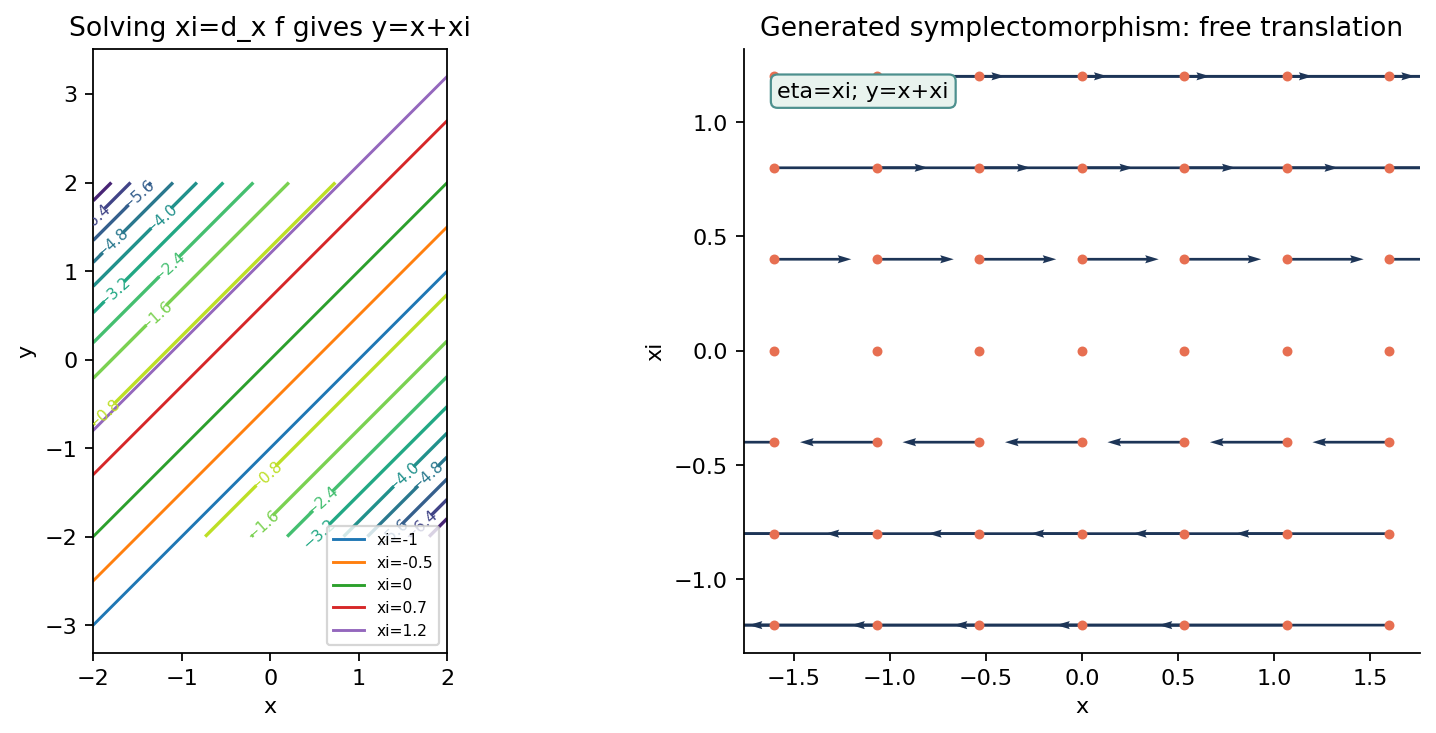

mixed Hessian implicit-function gate -> artifacts\lecture-04\figures\mixed-hessian-implicit-function-gate.png


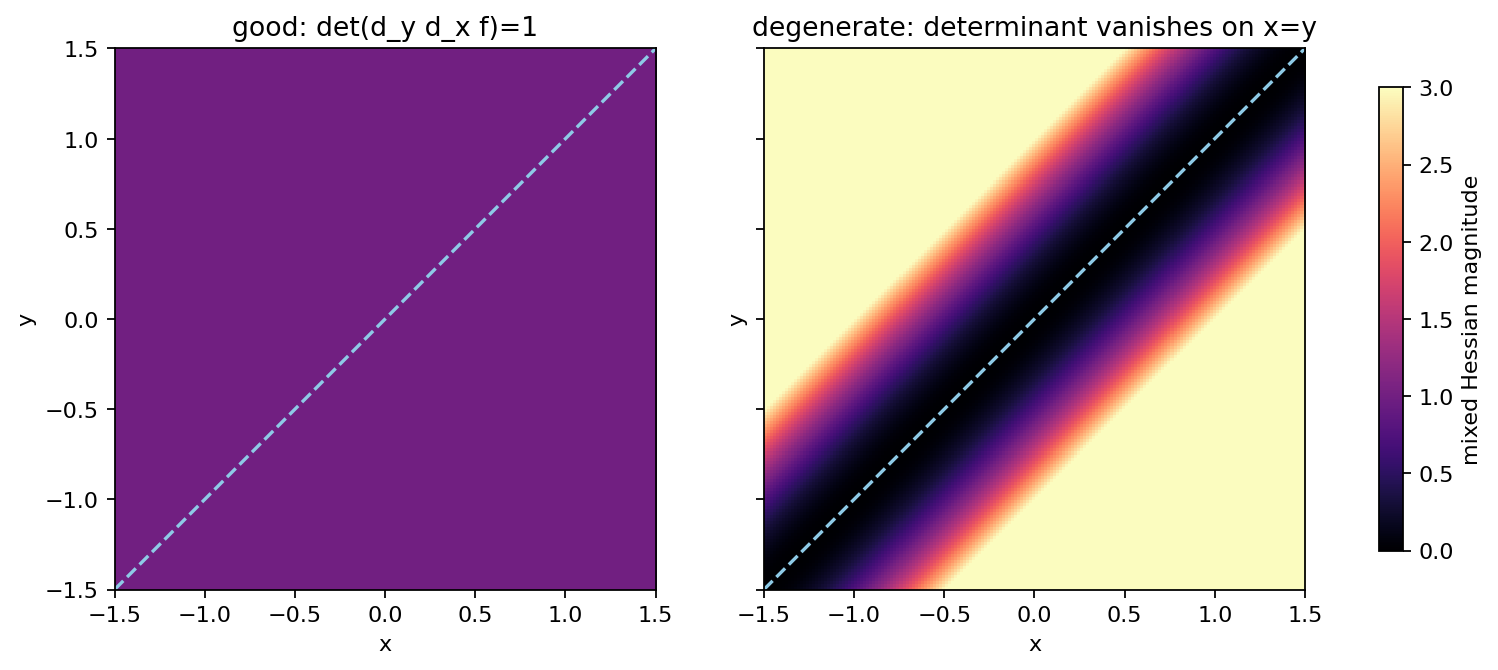

twist recipe -> artifacts\lecture-04\figures\generating-function-twist-recipe.png


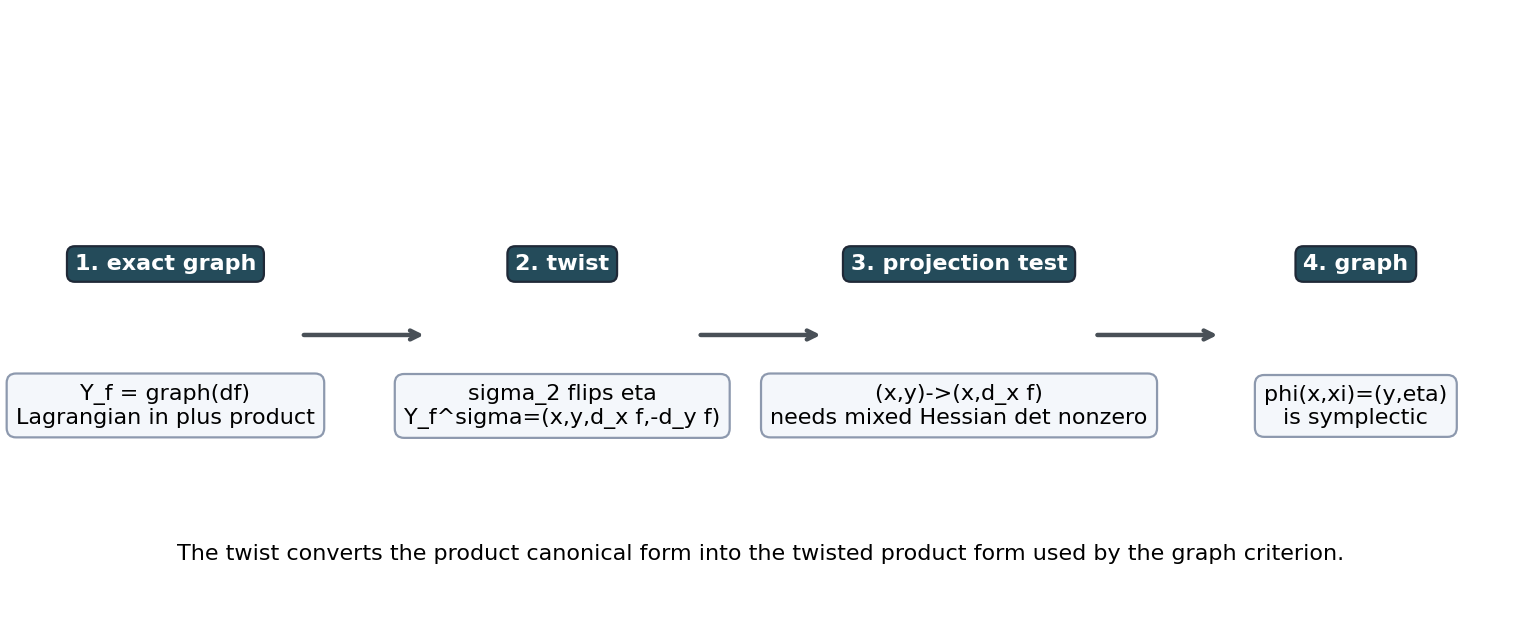

geodesic-flow generating function -> artifacts\lecture-04\figures\geodesic-flow-distance-generating-function.png


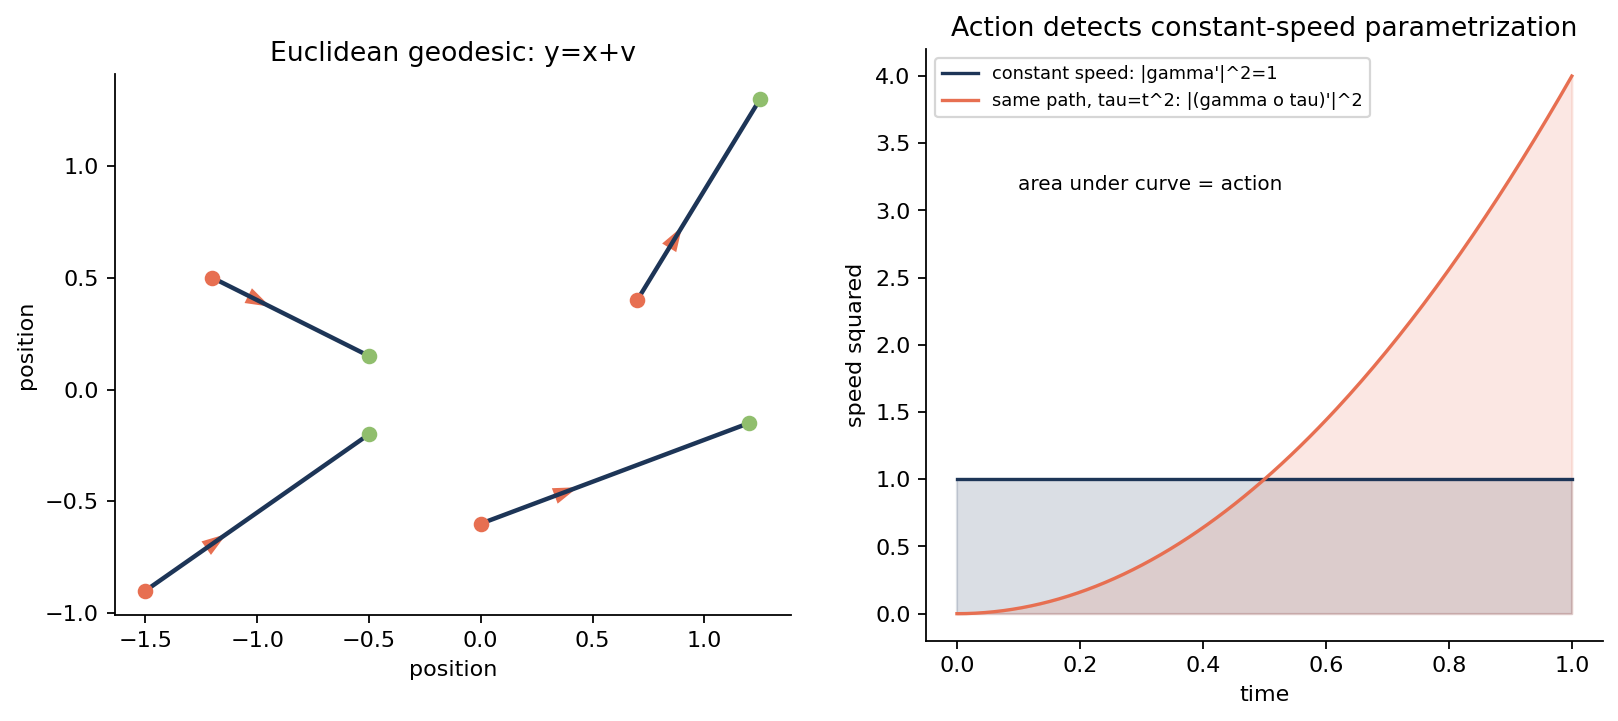

generating-functions proof route -> artifacts\lecture-04\figures\generating-functions-proof-route.png


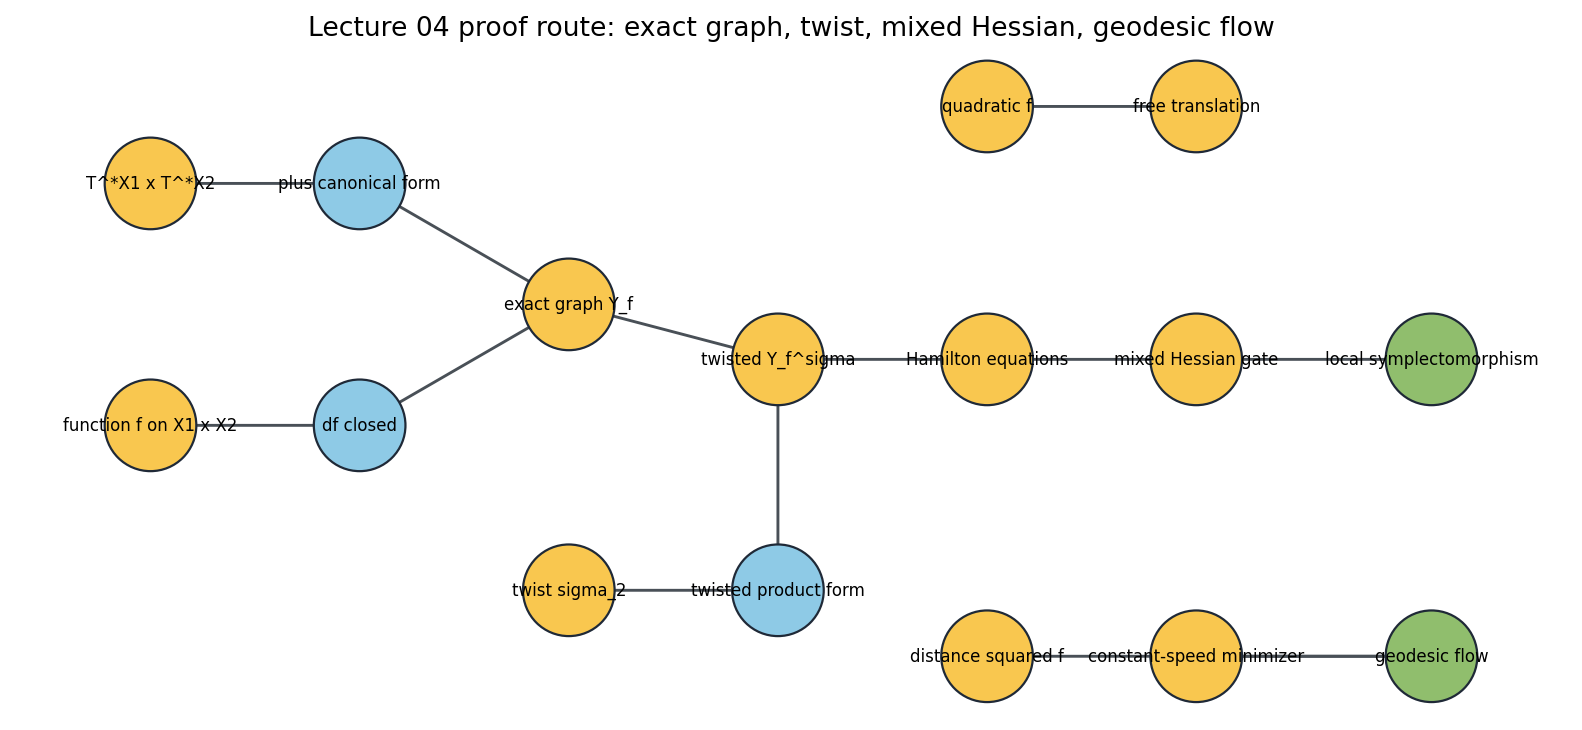

In [9]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- A generating function `f` first gives the exact Lagrangian graph of `df` in the plus product cotangent bundle.
- Flipping the second cotangent fiber turns that Lagrangian into a candidate graph for the twisted product form.
- The mixed Hessian `d_y d_x f` is the local gate that lets one solve `xi=d_x f` for `y`.
- The quadratic generator `-(x-y)^2/2` produces free Euclidean motion `(x,xi)->(x+xi,xi)`.
- The Riemannian distance-squared generator generalizes the same idea to geodesic flow under the metric identification `TX ~= T^*X`.
- The homework action calculation explains why constant-speed minimizing geodesics are the variational paths selected by the construction.

**Exploration prompt.** Replace the quadratic generator by `-(x-y)^2/2 + eps*cos(y)`. For small `eps`, compute the mixed Hessian and determine where the generated map is locally defined.